<img src='../../../common/DH_LOGO.jpeg' align='left' width=100%/>

In [ ]:
# initial setup
#%run "../../../common/0_notebooks_base_setup.py"

# DHDSPaDM3A22 - Prática Guiada: Checkpoint Vídeo

## Regressão linear

Vamos trabalhar com um conjunto de dados de [aluguel de bicicletas](https://www.kaggle.com/ammarsahyoun/bike-rental-demand) que foi usado em um concurso Kaggle. Os dados de aluguel por hora são fornecidos por dois anos.

Queremos prever o número total de bicicletas alugadas usando apenas as informações disponíveis no conjunto de treinamento.

**CAMPOS DO DATASET**

- `datetime` - Dia e hora - `timestamp`
- `season` -  1 = primavera', 2 = verão, 3 = outono, 4 = inverno
- `holiday` - Feriado
- `workingday` - Se for um dia da semana (1) ou fim de semana (0)
- `weather` - 
      1: Clear, Few clouds
      2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
      3: Light Snow, Light Rain + Thunderstorm + Scattered clouds,Light Rain + Scattered clouds
      4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 

- `temp` - temperatura em Celsius
- `atemp` - sensação térmica
- `humidity` - humidade
- `windspeed` - velocidade do vento
- `casual` - ususários não-registrados (number of non-registered user rentals initiated)
- `registered` - ususários registrados (number of registered user rentals initiated)
- `count` - total de aluguéis

Observe que este conjunto de dados contém variáveis contínuas e categóricas, veremos mais tarde como trabalhar com os dois tipos. Da mesma forma, observamos que existem variáveis que devido a sua composição não podem ser utilizadas para predizer o resultado. É o caso dos dados das colunas `casual` e `registrado`, que juntas somam o resultado a ser previsto.

In [63]:
# Importar libreria de pandas 
# Leia os dados de '../Data/bikes.csv' e defina a data e hora como índice.
import pandas as pd
bikes = pd.read_csv('../Data/bikes.csv', 
                    index_col = 'datetime', 
                    parse_dates = True
                   )
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [64]:
# Observe as dimensões do dataframe
bikes.shape

(10886, 11)

In [65]:
# Tomamos uma amostra de 10 observações (método de amostra)
bikes.sample(10)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2012-08-16 15:00:00,3,0,1,1,32.80,34.850,33,16.9979,63,197,260
2011-11-11 16:00:00,4,1,0,1,14.76,16.665,34,22.0028,49,189,238
2011-09-05 05:00:00,3,1,0,2,27.06,31.060,74,11.0014,2,4,6
2011-03-17 20:00:00,1,0,1,1,17.22,21.210,67,15.0013,25,112,137
2011-03-12 21:00:00,1,0,0,1,15.58,19.695,62,0.0000,36,46,82
2012-08-02 21:00:00,3,0,1,1,31.16,36.365,66,15.0013,41,301,342
2011-04-01 07:00:00,2,0,1,3,9.84,12.120,93,0.0000,4,91,95
2012-05-05 09:00:00,2,0,0,1,25.42,29.545,78,7.0015,61,223,284
2011-03-11 00:00:00,1,0,1,2,13.94,17.425,100,6.0032,0,6,6


In [66]:
# Uma vez que "count" é um método pandas, renomeamos a coluna "count" para "total":
bikes.rename(columns = {'count' : 'total'}, 
             inplace = True
            )

In [67]:
bikes.sample(10)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total
datetime,,,,,,,,,,,
2012-01-04 10:00:00,1,0,1,1,2.46,5.305,45,0.0000,7,57,64
2012-02-07 16:00:00,1,0,1,1,18.04,21.970,35,16.9979,19,257,276
2012-02-11 13:00:00,1,0,0,2,10.66,12.120,81,19.0012,18,217,235
2011-11-02 10:00:00,4,0,1,1,16.40,20.455,71,6.0032,25,108,133
2011-11-10 10:00:00,4,0,1,2,18.04,21.970,88,15.0013,17,100,117
2011-01-11 21:00:00,1,0,1,3,6.56,9.850,86,6.0032,0,20,20
2012-06-03 06:00:00,2,0,0,1,18.86,22.725,82,7.0015,6,16,22
2012-05-15 22:00:00,2,0,1,1,23.78,27.275,78,15.0013,9,74,83
2012-02-18 16:00:00,1,0,0,1,18.04,21.970,44,22.0028,186,218,404


# Regressão Linear

Construir um modelo em [Scikit-Learn](https://scikit-learn.org/stable/) leva $5$ passos.

1. Preparar os dados em uma matriz de `features` e um vetor `target`.

2. Escolher um modelo importando a [classe de estimador](https://towardsdatascience.com/object-oriented-programming-for-data-scientists-build-your-ml-estimator-7da416751f64) apropriada do `Scikit-Learn`.

3. Selecionar os hiperparâmetros do modelo instanciando a classe com os valores desejados.

4. Ajustar o modelo aos dados, invocando o método `.fit()` da instância do modelo.

5. Aplicar o modelo a novos dados.

Começamos com uma regressão linear simples.

## Regressão Linear Simples

Realizamos uma regressão linear simples quando usamos uma única variável para prever a variável de dependente. Em nosso exemplo, vamos escolher trabalhar com a temperatura como variável preditora.

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Definimos parâmetros globais para matplotlib.
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 16

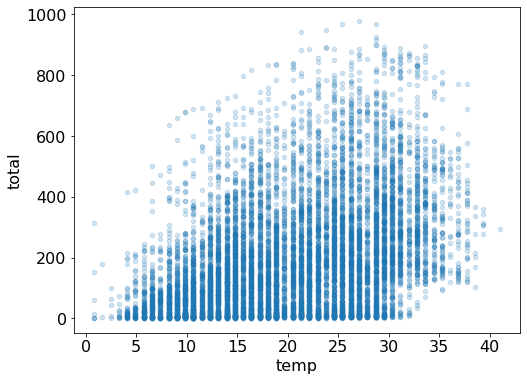

In [70]:
# Executamos um gráfico de dispersão com 'temp' no 'eixo x' e 'total' no 'eixo y'
bikes.plot(kind = 'scatter', 
           x = 'temp', 
           y = 'total', 
           alpha = 0.2
          );

In [71]:
# De agora em diante, usaremos um arranjo 'features_cols' 
# para armazenar as features que usaremos para treinar o modelo.

feature_cols = []

In [72]:
# instanciamos `feature_cols` com 'temp' como o único argumento
# Em seguida, criamos os arranjos de variáveis independentes X usando `feature_cols` como 
# máscara de nosso dataframe e finalmente geramos o arranjo da variável dependente, usando a coluna 'total'

feature_cols = ['temp']
X = bikes[feature_cols]
y = bikes['total']

In [73]:
# Importamos o pacote, instanciamos o estimador e ajustamos o modelo (sklearn "clássico")

from sklearn.linear_model import LinearRegression

In [74]:
# Instanciamos o modelo

linreg = LinearRegression()

In [75]:
# Treinamos o modelo com todo o dataset (não usaremos train-test-split nessa oportunidade)

linreg.fit(X, y)

LinearRegression()

In [76]:
# Imprima os coeficientes e a interceptação do modelo treinado

print(linreg.intercept_)
print(linreg.coef_)

6.046212959616781
[9.17054048]


Interpretação do interceptador ($\beta_{0}$):

- É o valor esperado de $ y $ quando $ x = 0 $ .

Interpretação do coeficiente de `temp` ($\beta_{1}$):

- É a variação $\Delta y$ em $ y $ dividido pela variação $\Delta x$ em $ x $, ou a inclinação da regressão.

$$
\beta_{1} = \frac{\Delta y}{\Delta x}
$$

- Assim, um aumento na temperatura de $1$ grau Celsius está  associado a um aumento no aluguel de $9.17$ bicicletas. O coeficiente $ \beta_{1} $ sería negativo se um aumento na temperatura se associasse a uma disminucição no número de aluguéis.

<img src='img/Simple_Linear_Regression.png' align='left' width=100%/>

### Usando o modelo para realizar previsões

Quantas bicicletas alugadas poderíamos prever se a temperatura fosse de $25$ graus Celsius?

In [77]:
# calcular o total de bicicletas alugadas usando a fórmula da linha com os parâmetros calculados 
# anteriormente
# y = b0 + b1 * x

temp = 25

linreg.intercept_ + linreg.coef_ * temp

array([235.309725])

In [78]:
# Faça o mesmo cálculo, mas prevendo com o modelo que treinamos.
# observação: você precisará converter a temperatura do inteiro em um np.array, pois o 
# modelo funciona com np.arrays
# (importar numpy)

import numpy as np

test_sklearn = np.array(temp).reshape(-1, 1)

#test_sklearn
linreg.predict(test_sklearn)

array([235.309725])

## Regressão Linear Múltipla

In [79]:
# Exploramos mais features
feature_cols = ['temp', 'weather', 'humidity']

In [80]:
# E a matriz de correlação (intervalo de +1 a -1)
bikes[feature_cols].corr()

,temp,weather,humidity
temp,1.000000,-0.055035,-0.064949
weather,-0.055035,1.000000,0.406244
humidity,-0.064949,0.406244,1.000000


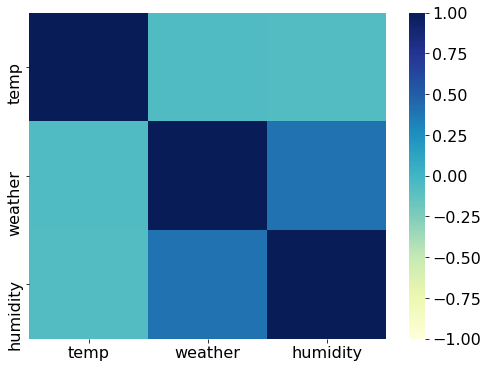

In [81]:
# visualizamos a matriz de correlação no Seaborn usando um mapa de calor
sns.heatmap(bikes[feature_cols].corr(), 
            vmin = -1, 
            vmax = 1, 
            center = 0, 
            cmap = "YlGnBu"
           );

In [82]:
# Como fizemos para a regressão linear simples, criamos X novamente (usando os novos `feature_cols`) e y
# Em seguida, instanciamos o modelo e o treinamos (novamente sem usar `train-test-split`).
# nota: instanciamos o modelo com o nome: 'linreg'
# Finalmente imprimimos os coeficientes do novo modelo.

X = bikes[feature_cols]
y = bikes['total']

# instanciamos e trenamos o modelo
linreg = LinearRegression()
linreg.fit(X, y)

# Imprimimos os coeficientes
print (linreg.intercept_)
print (linreg.coef_)

183.23969390859926
[ 8.73698147  3.77938867 -2.80809402]


In [83]:
## Para observarmos melhor associamos o nome ao coeficiente
list(zip(feature_cols, linreg.coef_))

[('temp', 8.73698146883967),
 ('weather', 3.7793886717573395),
 ('humidity', -2.80809402367535)]

## Escolhemos entre os modelos

### Métricas de avaliação para problemas de regressão

Existem três métricas de avaliação comuns para problemas de regressão:

O **Mean Absolute Error (MAE)** é a média do valor absoluto dos erros:

$$ \frac 1n\sum_ {i = 1}^n |y_i-\hat{y}_i| $$

O **Mean Squared Error (MSE)**  é a média dos erros quadráticos:

$$ \frac 1n\sum_ {i = 1}^n(y_i- \hat{y}_i)^2 $$

A **Root Mean Square Error (RMSE)** é a raiz quadrada da média dos erros quadráticos:

$$ \sqrt{\frac 1n\sum_{i = 1}^n(y_i- \hat{y}_i)^2} $$

todas estas são funções custo, que queremos minimizar.

In [84]:
# Exemplo de valores de resposta verdadeiros e previstos
true = [10, 7, 5, 5, 10, 8, 8, 15, 12]
pred = [12, 8, 3, 4, 12, 9, 8, 12, 13]

In [85]:
# Calculamos as métricas manualmente? Claro que não!

from sklearn import metrics
import numpy as np

print ('MAE:', metrics.mean_absolute_error(true, pred))
print ('MSE:', metrics.mean_squared_error(true, pred))
print ('RMSE:', np.sqrt(metrics.mean_squared_error(true, pred)))
print ('R2:', metrics.r2_score(true, pred))

MAE: 1.4444444444444444
MSE: 2.7777777777777777
RMSE: 1.6666666666666667
R2: 0.7054973821989529


## Comparando modelos usando conjuntos de treino e teste e RMSE

In [86]:
# Definios uma função e a chamamos de 'train_test_error', ela aceita como parâmetro uma lista de recursos (feature_cols),
# A função gera a matriz de variáveis independentes 'X' e a matriz da variável dependentes 'y'
# em seguida, ela faz a divisão entre conjuntos de treino e teste, reservando 25% das observações para teste,
# e finalmente imprime os erros MAE, MSE, RMSE e R2

from sklearn.model_selection import train_test_split

def train_test_error(feature_cols):
    X = bikes[feature_cols]
    y = bikes['total']
    # Como estamos trabalhando com observações ordenadas no tempo, usamos
    # `shuffle = False` para evitar data leakage
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle = False)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    y_pred = linreg.predict(X_test)
    
    
    print (feature_cols)
    print ("y_test sample: ", y_test.values[0: 10])
    print ("y_pred sample: ", y_pred[0: 10].astype(int))
    print ('MAE:', metrics.mean_absolute_error(y_test, y_pred))
    print ('MSE:', metrics.mean_squared_error(y_test, y_pred))
    print ('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
    print ('R2:', metrics.r2_score(y_test, y_pred))
    print ()
    return 

In [87]:
# Usando a função 'train_test_error' recém-criada, comparamos diferentes ensembles de features.
# teste primeiro com `feature_cols = ['temp', 'umidade']`
# e então com `feature_cols = ['temp', 'umidade', 'velocidade do vento']`
# Que observações você pode fazer sobre os resultados?

train_test_error(['temp', 'humidity'])
train_test_error(['temp', 'humidity','windspeed'])

['temp', 'humidity']
y_test sample:  [420 444 345 313 413 370 382 332 258 151]
y_pred sample:  [394 394 377 394 411 382 351 351 351 334]
MAE: 154.60330484672812
MSE: 44002.98797986697
RMSE: 209.76889183066913
R2: 0.05953123509528557

['temp', 'humidity', 'windspeed']
y_test sample:  [420 444 345 313 413 370 382 332 258 151]
y_pred sample:  [394 394 378 395 412 384 349 349 349 332]
MAE: 154.54203361463797
MSE: 43999.997678572574
RMSE: 209.76176410054472
R2: 0.0595951463225487



# Criando Features

## Manipulação de variáveis categóricas

O `Scikit-learn` espera que todos os recursos sejam numéricos. Então, como incluímos um recurso categórico em nosso modelo?

- ** Categorias ordenadas: ** transforme-as em valores numéricos que representam essa ordem

- ** Categorias não ordenadas: ** use variáveis fictícias (0/1) (Variáveis-dummies)

Quais são as características categóricas de nosso conjunto de dados?

- ** Categorias classificadas: ** clima (já codificado com valores numéricos que representam ordem)

- ** Categorias não ordenadas: ** temporada (precisa de variáveis ​​dummies), feriado (já está codificado como fictícia), dia útil (já está codificado como fictícia)

Para a estação, não podemos simplesmente deixar a codificação como $1 = primavera, 2 = verão, 3 = outono e 4 = inverno$, porque isso implicaria em uma ** relação ordenada. Em vez disso, criamos ** variáveis fictícias:

In [88]:
# criar variáveis dummies
season_dummies = pd.get_dummies(bikes['season'], 
                                prefix = 'season'
                               )

# imprimimos para ver 5 linhas quaisquer
season_dummies.sample(n = 5, random_state = 1)

,season_1,season_2,season_3,season_4
datetime,,,,
2011-09-05 11:00:00,0,0,1,0
2012-03-18 04:00:00,1,0,0,0
2012-10-14 17:00:00,0,0,0,1
2011-04-04 15:00:00,0,1,0,0
2012-12-11 02:00:00,0,0,0,1


Nota: O método [`get_dummies`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) converte variáveis categóricas em variáveis `dummy`.

No entanto, realmente são necessárias apenas de três variáveis fictícias e não quatro, para descrever o problema e, portanto, vamos descartar a primeira variável fictícia. Por quê?

In [89]:
# Eliminamos a primeira coluna, que é redundante
season_dummies.drop(season_dummies.columns[0], 
                    axis = 1, 
                    inplace = True
                   )

# imprimimos cinco observaçÕes quaisquer
season_dummies.sample(n = 5, 
                      random_state = 1
                     )

,season_2,season_3,season_4
datetime,,,
2011-09-05 11:00:00,0,1,0
2012-03-18 04:00:00,0,0,0
2012-10-14 17:00:00,0,0,1
2011-04-04 15:00:00,1,0,0
2012-12-11 02:00:00,0,0,1


Em geral, se você tem uma feature categórica com $k$ valores possíveis, você deve criar $k - 1 $ variáveis fictícias.

In [90]:
# Concatenamos o DataFrame original e o dummy DataFrame (eixo = 0 significa linhas, eixo = 1 significa colunas)
bikes = pd.concat([bikes, season_dummies], 
                  axis = 1
                 )

# imprimimos cinco observações quaisquer
bikes.sample(n = 5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,season_2,season_3,season_4
datetime,,,,,,,,,,,,,,
2012-03-05 19:00:00,1,0,1,1,10.66,12.880,53,15.0013,6,220,226,0,0,0
2012-10-07 05:00:00,4,0,0,2,18.04,21.970,54,8.9981,2,8,10,0,0,1
2011-10-07 11:00:00,4,0,1,1,22.96,26.515,63,0.0000,80,150,230,0,0,1
2012-02-10 11:00:00,1,0,1,2,11.48,14.395,45,7.0015,19,134,153,0,0,0
2012-04-09 14:00:00,2,0,1,1,22.96,26.515,28,36.9974,66,152,218,1,0,0


In [91]:
# agora usamos a função `train_test_error` que definimos anteriormente com
# os últimos recursos selecionados (feature_cols = ['temp', 'umidade', 'velocidade do vento', 'season_2', 'season_3', 'season_4'])

train_test_error(['temp', 'humidity','windspeed', 'season_2', 'season_3', 'season_4'])

['temp', 'humidity', 'windspeed', 'season_2', 'season_3', 'season_4']
y_test sample:  [420 444 345 313 413 370 382 332 258 151]
y_pred sample:  [363 363 346 364 380 350 313 313 313 295]
MAE: 150.60954131647804
MSE: 43943.74251077739
RMSE: 209.62762821435868
R2: 0.0607974789505068



Uma ligeira melhora é observada em R2, mas não muito significativa.

### Continuamos com a feature engineering

Criamos os seguintes recursos:

- `tempo` - como uma variável fictícia (de 0 a 23),

- `dia` -  como uma característica categórica (dia = 1 das 7h às 20h e dia = 0 caso contrário)

In [92]:
# Geramos variáveis dummies a partir de `hora`
bikes['hora'] = bikes.index.hour
bikes_dummies = pd.get_dummies(bikes.index.hour, 
                               drop_first = True
                              )
bikes_dummies.index = bikes.index

In [94]:
bikes_dummies.head()

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 01:00:00,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 02:00:00,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 03:00:00,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 04:00:00,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
# Concatenamos as variáveis dummies ao dataframe original
bikes  = pd.concat([bikes, bikes_dummies], 
                   axis = 1
                  )

In [96]:
# Criamos días como categórica
dia = (bikes.index.hour >= 7) & (bikes.index.hour <= 20)
dia

array([False, False, False, ..., False, False, False])

In [97]:
# Agregamos a coluna de dia
bikes['dia'] = dia.astype(int)
bikes['dia'].sample(5)

datetime
2012-02-13 14:00:00    1
2011-04-17 01:00:00    0
2012-06-01 03:00:00    0
2012-02-17 02:00:00    0
2011-08-17 21:00:00    0
Name: dia, dtype: int64

In [99]:
# Por ultimo aplicamos nossa função `train_test_error` sobre o novo cojunto de features:
# ['temp','humidity','windspeed', 'season_2', 'season_3', 'season_4',1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

train_test_error(['temp',
                  'humidity',
                  'windspeed', 
                  'season_2', 
                  'season_3', 
                  'season_4', 
                  'dia', 
                  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23
                 ])


['temp', 'humidity', 'windspeed', 'season_2', 'season_3', 'season_4', 'dia', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
y_test sample:  [420 444 345 313 413 370 382 332 258 151]
y_pred sample:  [319 302 295 359 509 458 360 290 249 210]
MAE: 110.93454063051192
MSE: 25343.03340212591
RMSE: 159.19495407243883
R2: 0.45834743464372496



## Conclusões: 

Vantagens da regressão linear:

- Simples de explicar
- Muito interpretável
- O treinamento e a previsão do modelo são rápidos
- É invariante a mudanças na escala das `features`.


Desvantagens da regressão linear:

- O desempenho (geralmente) não é competitivo com os melhores métodos de aprendizado supervisionado devido ao alto viés.